In [1]:
import pandas as pd

df = pd.read_csv("data/train.csv")
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


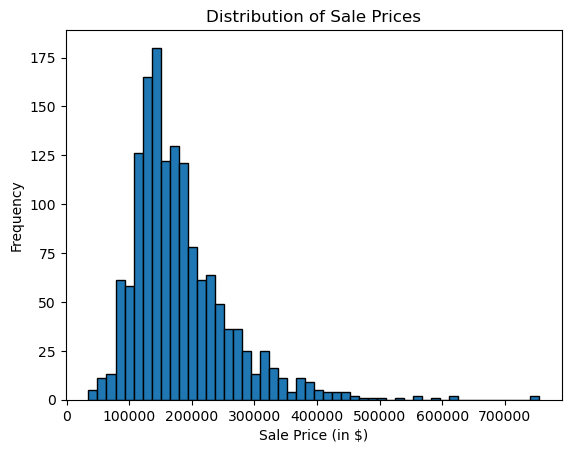

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plt.hist(df["SalePrice"], bins = 50, edgecolor = 'black')
plt.xlabel("Sale Price (in $)")
plt.ylabel("Frequency")
plt.title("Distribution of Sale Prices")
plt.show()


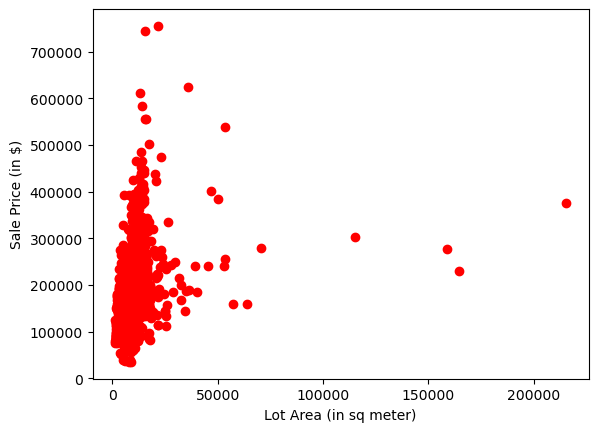

In [3]:
plt.scatter(x = df['LotArea'], y = df['SalePrice'], color = 'red' )
plt.xlabel("Lot Area (in sq meter)")
plt.ylabel("Sale Price (in $)")
plt.show()

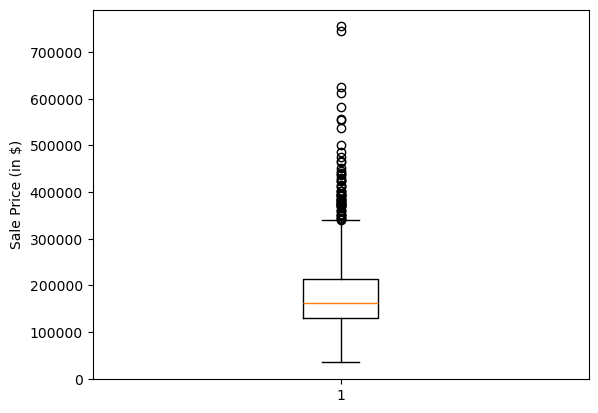

In [4]:
plt.boxplot(df['SalePrice'])
plt.ylabel("Sale Price (in $)")
plt.show()


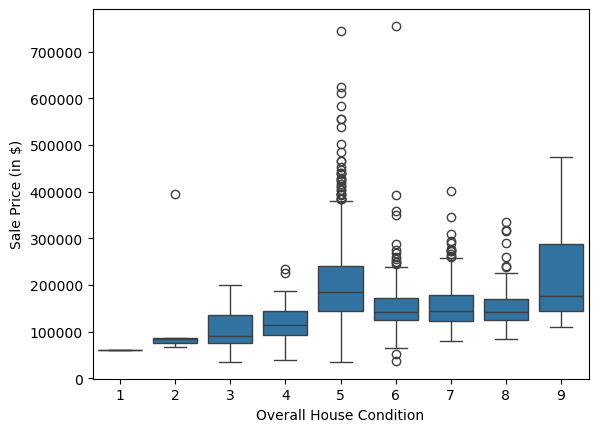

In [5]:
import seaborn as sns
sns.boxplot(x = 'OverallCond', y = 'SalePrice', data = df)
plt.ylabel("Sale Price (in $)")
plt.xlabel("Overall House Condition")
plt.show()

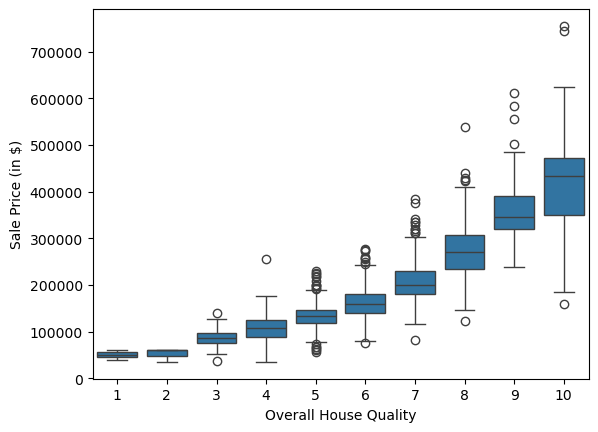

In [6]:
sns.boxplot(x = 'OverallQual', y = 'SalePrice', data = df)
plt.ylabel("Sale Price (in $)")
plt.xlabel("Overall House Quality")
plt.show()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
pd.set_option('display.max_rows', None)
df.isnull().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
FireplaceQu       690
LotFrontage       259
GarageQual         81
GarageFinish       81
GarageType         81
GarageYrBlt        81
GarageCond         81
BsmtFinType2       38
BsmtExposure       38
BsmtCond           37
BsmtQual           37
BsmtFinType1       37
MasVnrArea          8
Electrical          1
Condition2          0
BldgType            0
Neighborhood        0
LandSlope           0
LotConfig           0
Condition1          0
LandContour         0
LotShape            0
Street              0
LotArea             0
MSSubClass          0
MSZoning            0
Id                  0
Utilities           0
HouseStyle          0
Foundation          0
ExterQual           0
ExterCond           0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
BsmtFinSF1          0
Exterior2nd         0
Exterior1st         0
RoofMatl            0
RoofStyle           0
YearRemodA

Cant delete any rows all NA means no feature

In [9]:
none_columns = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtFinType1', 'BsmtFinType2', 'BsmtExposure', 'BsmtCond', 'BsmtQual',
    'MasVnrType'
]
df[none_columns] = df[none_columns].fillna('None')

df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

df.isnull().sum().sort_values(ascending=False).head(10)

Id             0
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
Street         0
Alley          0
LotShape       0
LandContour    0
Utilities      0
dtype: int64

In [10]:
# First train the data only on overallquality

X = df[['OverallQual']].values

y = df['SalePrice'].values



from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2*100}")


Mean Squared Error: 2681026163.509091
R-squared: 65.04677778896863


In [11]:
#Now all numerical features will be used to train the model

X_all_numeric = df.select_dtypes(include=['int64', 'float64']).drop(columns=['SalePrice', 'Id'])
y = df['SalePrice'].values

X_train_allnumeric, X_test_allnumeric, y_train, y_test = train_test_split(X_all_numeric, y, test_size=0.2, random_state=42)

model_allnumeric = LinearRegression()
model_allnumeric.fit(X_train_allnumeric, y_train)

y_pred_allnumeric = model_allnumeric.predict(X_test_allnumeric)

mse_allnumeric = mean_squared_error(y_test, y_pred_allnumeric)
r2_allnumeric = r2_score(y_test, y_pred_allnumeric)
print(f"Mean Squared Error (All Numeric Features): {mse_allnumeric}")
print(f"R-squared (All Numeric Features): {r2_allnumeric*100}")

Mean Squared Error (All Numeric Features): 1357232156.8266158
R-squared (All Numeric Features): 82.30541804656386


In [12]:
#Converting psuedo-numerical features to categorical features

text_columns = df.select_dtypes(exclude=['int64', 'float64'])

print(f"Total categorical columns to encode: {len(text_columns.columns)}")
print(text_columns.columns.tolist())

df['MSSubClass'] = df['MSSubClass'].astype(str)
df['MoSold'] = df['MoSold'].astype(str)

print("Categorical columns:", len(df.select_dtypes(exclude=['int64', 'float64']).columns))



Total categorical columns to encode: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Categorical columns: 45


In [13]:
# One-hot encode all categorical text columns automatically
df_encoded = pd.get_dummies(df, drop_first=True)

# Print out the new shape of your dataset to see how many columns we have now!
print(f"Original dataset shape: {df.shape}")
print(f"Encoded dataset shape: {df_encoded.shape}")

Original dataset shape: (1460, 81)
Encoded dataset shape: (1460, 284)


In [14]:
# 1. Isolate target and features cleanly
X_all_features = df_encoded.drop(columns=['SalePrice', 'Id'])
y_all_features = df_encoded['SalePrice'].values

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_all_features, y_all_features, test_size=0.2, random_state=42)

# 3. Train the model
model_allfeatures = LinearRegression()
model_allfeatures.fit(X_train, y_train)

# 4. Predict and evaluate
y_pred_allfeatures = model_allfeatures.predict(X_test)
mse_allfeatures = mean_squared_error(y_test, y_pred_allfeatures)
r2_allfeatures = r2_score(y_test, y_pred_allfeatures)

print(f"True All-Features R-squared: {r2_allfeatures * 100:.2f}%")

True All-Features R-squared: -7.14%


In [15]:
#Try using Other Models to see if we can improve the model's performance

from sklearn.linear_model import Ridge

# 1. Use the exact same X_train and y_train you just split
# Ridge() adds that magic protective penalty layer
model_ridge = Ridge(alpha=1.0) 
model_ridge.fit(X_train, y_train)

# 2. Predict and evaluate
y_pred_ridge = model_ridge.predict(X_test)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression R-squared (All Features): {r2_ridge * 100:.2f}%")


# from sklearn.linear_model import LogisticRegression

# model_logistic = LogisticRegression()
# model_logistic.fit(X_train, y_train)

# y_pred_logistic = model_logistic.predict(X_test)
# r2_logistic = r2_score(y_test, y_pred_logistic)

# print(f"Logistic Regression R-squared (All Features): {r2_logistic * 100:.2f}%")

from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) 
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest R-squared (All Features): {r2_rf * 100:.2f}%")

from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree R-squared (All Features): {r2_dt * 100:.2f}%")


Ridge Regression R-squared (All Features): 87.60%
Random Forest R-squared (All Features): 89.08%
Decision Tree R-squared (All Features): 76.45%


In [30]:
#Hand picking the best catagorical features and converting them into numerical features 

neighborhood_map = {
   # Elite Luxury (Tier 6)
    'StoneBr': 6, 'NridgHt': 6, 'NoRidge': 6,
    
    # High-End Premium (Tier 5)
    'Veenker': 5, 'Timber': 5, 'Somerst': 5, 'ClearCr': 5, 'Crawfor': 5,
    
    # Upper-Middle Suburbs (Tier 4)
    'CollgCr': 4, 'Blmngtn': 4, 'Gilbert': 4, 'NWAmes': 4, 'SawyerW': 4,
    
    # Mid-Market Baseline (Tier 3)
    'Mitchel': 3, 'NAmes': 3, 'NPkVill': 3, 'Blueste': 3,
    
    # Value Zones & High Outlier Areas (Tier 2)
    'Sawyer': 2, 'SWISU': 2, 'BrkSide': 2, 'Edwards': 2, 'OldTown': 2,
    
    # High-Affordability Core (Tier 1)
    'BrDale': 1, 'IDOTRR': 1, 'MeadowV': 1
}

# 1. Map the text values into your new numeric ranking column
df['NghbrhdRank'] = df['Neighborhood'].map(neighborhood_map)

zoning_map = {
    'FV': 4,       # Floating Village (Highest premium)
    'RL': 3,       # Residential Low Density (Great premium)
    'RP': 3,       
    'RM': 2,       # Merged Medium and High density into a single baseline level
    'RH': 2,       
    'C (all)': 1,  # Commercial/Industrial/Ag (Lowest)
    'I': 1,        
    'A': 1         
}

# 1. Map the text values into your new numeric zoning column
df['ZoningRank'] = df['MSZoning'].map(zoning_map)


# Verify by checking the columns side-by-side
print(df[['MSZoning', 'ZoningRank']].head(10))

qual_map = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
    'None': 0  # 0 indicates no basement exists at all
}

# 2. Add BOTH basement columns to our master engineering list
qual_cols = ['ExterQual','ExterCond', 'KitchenQual', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'PoolQC', 'FireplaceQu', 'GarageQual', 'GarageCond']

# 3. Process them all in one clean run
for col in qual_cols:
    # Fill actual string 'NA' or missing entries with 'None'
    df[col] = df[col].fillna('None')
    df[col + 'Rank'] = df[col].map(qual_map)

df.info()

  MSZoning  ZoningRank
0       RL           3
1       RL           3
2       RL           3
3       RL           3
4       RL           3
5       RL           3
6       RL           3
7       RL           3
8       RM           2
9       RL           3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 95 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                1460 non-null   int64  
 1   MSSubClass        1460 non-null   object 
 2   MSZoning          1460 non-null   object 
 3   LotFrontage       1460 non-null   float64
 4   LotArea           1460 non-null   int64  
 5   Street            1460 non-null   object 
 6   Alley             1460 non-null   object 
 7   LotShape          1460 non-null   object 
 8   LandContour       1460 non-null   object 
 9   Utilities         1460 non-null   object 
 10  LotConfig         1460 non-null   object 
 11  LandSlope         1460 n

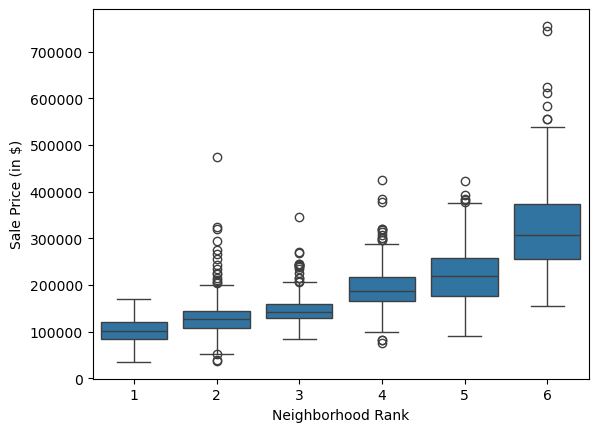

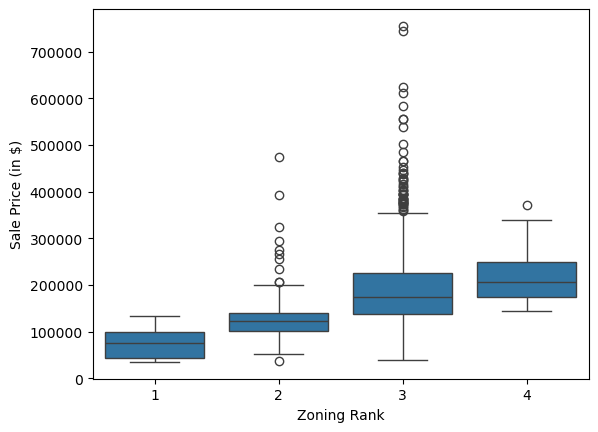

In [17]:
sns.boxplot(x = 'NghbrhdRank', y = 'SalePrice', data = df)
plt.ylabel("Sale Price (in $)")
plt.xlabel("Neighborhood Rank")
plt.show()

sns.boxplot(x = 'ZoningRank', y = 'SalePrice', data = df)
plt.ylabel("Sale Price (in $)")
plt.xlabel("Zoning Rank")
plt.show()

In [18]:
#Train the new model using numeical features and the newly created categorical features

X_all_numeric_new = df.select_dtypes(include=['int64', 'float64']).drop(columns=['SalePrice', 'Id'])
y = df['SalePrice'].values

X_train_allnumeric_new, X_test_allnumeric_new, y_train, y_test = train_test_split(X_all_numeric_new, y, test_size=0.2, random_state=42)

model_allnumeric = LinearRegression()
model_allnumeric.fit(X_train_allnumeric_new, y_train)

y_pred_allnumeric = model_allnumeric.predict(X_test_allnumeric_new)

mse_allnumeric = mean_squared_error(y_test, y_pred_allnumeric)
r2_allnumeric = r2_score(y_test, y_pred_allnumeric)
print(f"Mean Squared Error (All New Numeric Features): {mse_allnumeric}")
print(f"R-squared (All New Numeric Features): {r2_allnumeric*100}")


Mean Squared Error (All New Numeric Features): 1205541606.5834632
R-squared (All New Numeric Features): 84.28304645695685


In [19]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Start with your curated high-impact features
selected_features = [
    'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 
    '1stFlrSF', 'FullBath', 'YearBuilt', 'YearRemodAdd', 'Fireplaces',
    'NghbrhdRank', 'ZoningRank', 'ExterQualRank', 'KitchenQualRank', 
    'BsmtQualRank', 'BsmtCondRank', 'HeatingQCRank', 'PoolQCRank'
]

# Create our training slice and drop any lingering missing rows cleanly
df_final = df[selected_features + ['SalePrice']].copy().fillna(0)

# 2. Isolate features and target
X_pure = df_final[selected_features].values
y_pure = df_final['SalePrice'].values

# 3. Split the data cleanly
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_pure, y_pure, test_size=0.2, random_state=42)

# 4. Apply the CRITICAL Log Transformation to our targets
y_train_log = np.log(y_train_p)
y_test_log = np.log(y_test_p)

# 5. Train standard, pure Linear Regression on log targets
pure_lr_model = LinearRegression()
pure_lr_model.fit(X_train_p, y_train_log)

# 6. Predict and evaluate in log space
y_pred_log = pure_lr_model.predict(X_test_p)
r2_pure_log = r2_score(y_test_log, y_pred_log)

print(f"Total Clean Features Mapped: {X_pure.shape[1]}")
print(f"Curated Pure Linear Regression (+ Log) R-squared: {r2_pure_log * 100:.2f}%")

Total Clean Features Mapped: 17
Curated Pure Linear Regression (+ Log) R-squared: 88.36%


In [20]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Gather all of your beautifully structured numerical & hand-ranked features
selected_features = [
    'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 
    '1stFlrSF', 'FullBath', 'YearBuilt', 'YearRemodAdd', 'Fireplaces',
    'NghbrhdRank', 'ZoningRank', 'ExterQualRank', 'KitchenQualRank', 
    'BsmtQualRank', 'BsmtCondRank', 'HeatingQCRank', 'PoolQCRank'
]

# Create our clean training slice
df_final = df[selected_features + ['SalePrice']].copy().fillna(0)

X_pure = df_final[selected_features].values
y_pure = df_final['SalePrice'].values

# 2. Split the data cleanly (80/20 train/test split)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_pure, y_pure, test_size=0.2, random_state=42)

# 3. 🪵 BRING IN THE LOG: Smooth out the right-skewed target prices
y_train_log = np.log(y_train_p)

# 4. Train standard, pure Linear Regression on the LOG targets
pure_lr_model = LinearRegression()
pure_lr_model.fit(X_train_p, y_train_log)

# 5. Predict on the test set (this outputs predictions in log space)
y_pred_log = pure_lr_model.predict(X_test_p)

# 6. 🔄 INVERSE TRANSFORM: Convert the log predictions back into real dollar amounts
y_pred_dollars = np.exp(y_pred_log)

# 7. Evaluate the TRUE score on the real, raw dollar prices!
r2_true_dollars = r2_score(y_test_p, y_pred_dollars)

print(f"Total Features Trained On: {X_pure.shape[1]}")
print(f"Final True Dollar R-squared Score: {r2_true_dollars * 100:.2f}%")

Total Features Trained On: 17
Final True Dollar R-squared Score: 89.29%


0        60
1        20
2        60
3        70
4        60
5        50
6        20
7        60
8        50
9       190
10       20
11       60
12       20
13       20
14       20
15       45
16       20
17       90
18       20
19       20
20       60
21       45
22       20
23      120
24       20
25       20
26       20
27       20
28       20
29       30
30       70
31       20
32       20
33       20
34      120
35       60
36       20
37       20
38       20
39       90
40       20
41       20
42       85
43       20
44       20
45      120
46       50
47       20
48      190
49       20
50       60
51       50
52       90
53       20
54       80
55       20
56      160
57       60
58       60
59       20
60       20
61       75
62      120
63       70
64       60
65       60
66       20
67       20
68       30
69       50
70       20
71       20
72       60
73       20
74       50
75      180
76       20
77       50
78       90
79       50
80       60
81      120
82       20
83  

In [27]:
num_features = df.select_dtypes(include=['int64', 'float64']).drop(columns=['SalePrice', 'Id']).shape[1]
print(f"Number of features: {num_features}")

Number of features: 45


In [32]:
#New features
df['Basement_Quality'] = df['BsmtQualRank'] * df['BsmtCondRank']
df['GarageQuality'] = df['GarageQualRank'] * df['GarageCondRank']
df['ExterereQuality'] = df['ExterQualRank'] * df['ExterCondRank']
df['OverallQuality'] = df['OverallQual'] * df['OverallCond']

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 97 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                1460 non-null   int64  
 1   MSSubClass        1460 non-null   object 
 2   MSZoning          1460 non-null   object 
 3   LotFrontage       1460 non-null   float64
 4   LotArea           1460 non-null   int64  
 5   Street            1460 non-null   object 
 6   Alley             1460 non-null   object 
 7   LotShape          1460 non-null   object 
 8   LandContour       1460 non-null   object 
 9   Utilities         1460 non-null   object 
 10  LotConfig         1460 non-null   object 
 11  LandSlope         1460 non-null   object 
 12  Neighborhood      1460 non-null   object 
 13  Condition1        1460 non-null   object 
 14  Condition2        1460 non-null   object 
 15  BldgType          1460 non-null   object 
 16  HouseStyle        1460 non-null   object 


In [38]:
x_n = df.select_dtypes(include=['int64', 'float64']).drop(columns=['SalePrice', 'Id'])

y = df['SalePrice'].values

x_train_new, x_test_new, y_train_new, y_test_new = train_test_split(x_n, y, test_size=0.2, random_state=42)

model_new = LinearRegression()
model_new.fit(x_train_new, y_train_new)

y_pred_new = model_new.predict(x_test_new)

mse_new = mean_squared_error(y_test_new, y_pred_new)
r2_new = r2_score(y_test_new, y_pred_new)
print(f"Mean Squared Error (All New Numeric Features): {mse_new}")
print(f"R-squared (All New Numeric Features): {r2_new*100}")

Mean Squared Error (All New Numeric Features): 1203049909.8787055
R-squared (All New Numeric Features): 84.31553134270295


In [42]:
x_n = df.select_dtypes(include=['int64', 'float64']).drop(columns=['SalePrice', 'Id'])
y_log = np.log1p(df['SalePrice'].values)  # <-- Log transform applied here

# 2. Split the data
x_train_new, x_test_new, y_train_new, y_test_new = train_test_split(
    x_n, y_log, test_size=0.2, random_state=42
)

# 3. Train the model
model_new = LinearRegression()
model_new.fit(x_train_new, y_train_new)

# 4. Predict (Note: These predictions will be in log scale!)
y_pred_log = model_new.predict(x_test_new)

# 5. Evaluate (R2 score remains valid on the log scale)
r2_new = r2_score(y_test_new, y_pred_log)
print(f"R-squared (Log Scale): {r2_new * 100:.2f}%")

# Convert log predictions back to actual dollar amounts
y_pred_dollars = np.expm1(y_pred_log)
y_test_dollars = np.expm1(y_test_new)

# Now you can calculate the true dollar error
rmse_dollars = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
r2_dollars = r2_score(y_test_dollars, y_pred_dollars)
print(f"R-squared (True Dollar Scale): {r2_dollars * 100:.2f}%")
print(f"Average Error: ${rmse_dollars:,.2f}")

R-squared (Log Scale): 90.31%
R-squared (True Dollar Scale): 89.83%
Average Error: $27,935.22
